### **CREDIT RISK PREDICTION**

### Business Understanding

1. *Problem Statement:*

    Perusahaan Fintech menghadapi risiko gagal bayar karena tidak semua nasabah mampu melunasi pinjaman.
    Ada dua jenis kesalahan yang perlu diminimalkan:
    - Menyetujui nasabah yang gagal bayar yang menyebapkan kerugian finansial langsung.
    - Menolak nasabah yang mampu bayar yang menyebapkan hilangnya potensi pendapatan.

2. *Objektive:*
    - Membangun model ML yang menghasilkan skor probabilitas gagal bayar.
    - Mengidentifikasi fitur-fitur yang paling berpengaruh untuk interpretabilitas stakeholder.

3. *Target variable:* 'loan_status' - Label 0 (Good) | Label 1 (Bad)

4. *Metrics:* Recall, ROC-AUC, F1-Score, Precision

### Setup & EDA awal

In [1]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RANDOM_STATE=42
np.random.seed(RANDOM_STATE) 

In [2]:
# load data
df = pd.read_csv('loan_data_2007_2014.csv')

print('===FINTECH CREDIT RISK MODELING===')
print('Ukuran dataset:', df.shape)
print('\n5 Baris teratas:')
df.head()

===FINTECH CREDIT RISK MODELING===
Ukuran dataset: (466285, 75)

5 Baris teratas:


,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print('Info dataset:')
df.info()

Info dataset:
<class 'pandas.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  str    
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  str    
 10  sub_grade                    466285 non-null  str    
 11  emp_title                    438697 non-null  str    
 12  emp_length                   445277 non-null  str    
 

In [4]:
# check missing values
missing = (df.isnull().sum().to_frame('Missing_Count'))
missing['Missing_Pct'] = (missing['Missing_Count'] / len(df) * 100)
missing = (missing.query('Missing_Count > 0').sort_values('Missing_Pct', ascending=False))
display(missing.head(25))

,Missing_Count,Missing_Pct
inq_fi,466285,100.000000
open_rv_24m,466285,100.000000
max_bal_bc,466285,100.000000
all_util,466285,100.000000
inq_last_12m,466285,100.000000
annual_inc_joint,466285,100.000000
verification_status_joint,466285,100.000000
dti_joint,466285,100.000000
total_cu_tl,466285,100.000000
il_util,466285,100.000000


In [5]:
# check data duplikat & statistik
print('Jumlah data duplikat:', df.duplicated().sum())
print('\nRingkasan statistik:')
df.describe()

Jumlah data duplikat: 0

Ringkasan statistik:


,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
count,466285.000000,4.662850e+05,4.662850e+05,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,4.662810e+05,466285.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,3.960090e+05,0.0,0.0,0.0
mean,233142.000000,1.307973e+07,1.459766e+07,14317.277577,14291.801044,14222.329888,13.829236,432.061201,7.327738e+04,17.218758,...,NaN,NaN,NaN,NaN,NaN,NaN,3.037909e+04,NaN,NaN,NaN
std,134605.029472,1.089371e+07,1.168237e+07,8286.509164,8274.371300,8297.637788,4.357587,243.485550,5.496357e+04,7.851121,...,NaN,NaN,NaN,NaN,NaN,NaN,3.724713e+04,NaN,NaN,NaN
min,0.000000,5.473400e+04,7.047300e+04,500.000000,500.000000,0.000000,5.420000,15.670000,1.896000e+03,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN
25%,116571.000000,3.639987e+06,4.379705e+06,8000.000000,8000.000000,8000.000000,10.990000,256.690000,4.500000e+04,11.360000,...,NaN,NaN,NaN,NaN,NaN,NaN,1.350000e+04,NaN,NaN,NaN
50%,233142.000000,1.010790e+07,1.194108e+07,12000.000000,12000.000000,12000.000000,13.660000,379.890000,6.300000e+04,16.870000,...,NaN,NaN,NaN,NaN,NaN,NaN,2.280000e+04,NaN,NaN,NaN
75%,349713.000000,2.073121e+07,2.300154e+07,20000.000000,20000.000000,19950.000000,16.490000,566.580000,8.896000e+04,22.780000,...,NaN,NaN,NaN,NaN,NaN,NaN,3.790000e+04,NaN,NaN,NaN
max,466284.000000,3.809811e+07,4.086083e+07,35000.000000,35000.000000,35000.000000,26.060000,1409.990000,7.500000e+06,39.990000,...,NaN,NaN,NaN,NaN,NaN,NaN,9.999999e+06,NaN,NaN,NaN


In [6]:
# check outliers
outliers = []
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    if df[col].nunique() > 2:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
        if outlier_count > 0:
            pct = round((outlier_count / len(df)) * 100, 2)
            outliers.append((col, outlier_count, pct))
outliers.sort(key=lambda x: x[1], reverse=True)

print('Jumlah outliers per column:')
for col, count, pct in outliers:
    print(f'{col}: {count} outlier ({pct}%)')

Jumlah outliers per column:
delinq_2yrs: 83302 outlier (17.87%)
last_pymnt_amnt: 70346 outlier (15.09%)
pub_rec: 61363 outlier (13.16%)
tot_coll_amt: 49750 outlier (10.67%)
inq_last_6mths: 36785 outlier (7.89%)
total_rec_int: 31138 outlier (6.68%)
recoveries: 24371 outlier (5.23%)
out_prncp_inv: 23381 outlier (5.01%)
out_prncp: 23331 outlier (5.0%)
collection_recovery_fee: 23206 outlier (4.98%)
revol_bal: 22879 outlier (4.91%)
total_rev_hi_lim: 21533 outlier (4.62%)
total_rec_prncp: 20649 outlier (4.43%)
annual_inc: 19899 outlier (4.27%)
total_pymnt_inv: 19052 outlier (4.09%)
total_pymnt: 19039 outlier (4.08%)
tot_cur_bal: 12264 outlier (2.63%)
installment: 11711 outlier (2.51%)
total_rec_late_fee: 10678 outlier (2.29%)
open_acc: 10440 outlier (2.24%)
total_acc: 8674 outlier (1.86%)
int_rate: 4904 outlier (1.05%)
collections_12_mths_ex_med: 3914 outlier (0.84%)
acc_now_delinq: 1732 outlier (0.37%)
mths_since_last_major_derog: 388 outlier (0.08%)
mths_since_last_delinq: 89 outlier (0.02

In [7]:
print('Distribusi target (loan_status):')
print(df['loan_status'].value_counts())

Distribusi target (loan_status):
loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64


### Data Cleaning and Preprocessing

In [8]:
# mapping target
BAD_LOAN = [
    'Default',
    'Charged Off',
    'In Grace Period',
    'Late (16-30 days)',
    'Late (31-120 days)',
    'Does not meet the credit policy. Status:Charged Off',
]
GOOD_LOAN = [
    'Current',
    'Fully Paid',
    'Does not meet the credit policy/ Status:Fully Paid'
]
VALID_STATUS = BAD_LOAN + GOOD_LOAN

df = df[df['loan_status'].isin(VALID_STATUS)].copy()
df['loan_status'] = df['loan_status'].isin(BAD_LOAN).astype(int)

print('Distribusi target setelah mapping:')
print(df['loan_status'].value_counts())

Distribusi target setelah mapping:
loan_status
0    408965
1     55332
Name: count, dtype: int64


In [9]:
LEAKAGE_COLS = [
    'Unnamed: 0', 'id', 'member_id', 'url', 'desc', 'title',
    'zip_code', 'emp_title', 'policy_code', 'pymnt_plan',
    'issue_d', 'funded_amnt', 'funded_amnt_inv', 'total_pymnt',
    'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
    'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
    'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
    'out_prncp', 'out_prncp_inv', 'sub_grade'
]
df.drop(columns=LEAKAGE_COLS, errors='ignore', inplace=True)
print('Ukuran dataset setelah di drop:', df.shape)

Ukuran dataset setelah di drop: (464297, 48)


In [10]:
# handle missing values
def handle_missing_values(df, theshold=70):
    df = df.copy()

    missing_pct = df.isnull().mean() * 100
    cols_to_drop = missing_pct[missing_pct > theshold].index.tolist()

    df.drop(columns=cols_to_drop, inplace=True)
    
    print('Handle missing value selesai.')
    print(f'Kolom dihapus (> {theshold}% missing):')
    for col in cols_to_drop:
        print('-', col)
    return df

In [11]:
def feature_enginering(df):
    df = df.copy()
    EPS = 1e-6

    annual_income = (
        df['annual_inc'].fillna(df['annual_inc'].median()).clip(lower=0)
    )

    monthly_income = annual_income / 12

    df['loan_income_ratio'] = (
        df['loan_amnt'] / (monthly_income + EPS)
    )

    df['installment_income_ratio'] = (
        df['installment'] / (monthly_income + EPS)
    )

    total_rev_limit = (
        df['total_rev_hi_lim']
        .fillna(df['total_rev_hi_lim'].median())
    )

    df['revol_bal_ratio'] = (
        df['revol_bal'] /
        (total_rev_limit + EPS)
    ).clip(upper=5)

    df['earliest_cr_line'] = pd.to_datetime(
        df['earliest_cr_line'],
        format='%b-%y',
        errors='coerce'
    )

    snapshot = pd.Timestamp('2014-12-31')
    
    df['credit_history_age'] = (
        (snapshot - df['earliest_cr_line'])
        .dt.days
        .div(365.25)
    )
    
    df['credit_history_age'] = (
        df['credit_history_age']
        .clip(lower=0)
        .fillna(df['credit_history_age'].median())
    )

    df['has_delinq'] = (
        df['mths_since_last_delinq']
        .notna()
        .astype(int)
    )

    total_balance = (
        df['tot_cur_bal']
        .fillna(0)
    )

    df['credit_income_ratio'] = (
        total_balance /
        (annual_income + EPS)
    )

    total_account = (
        df['total_acc']
        .fillna(df['total_acc'].median())
        .clip(lower=1)
    )

    inquiry = (
        df['inq_last_6mths']
        .fillna(0)
    )

    df['inq_ratio'] = inquiry / total_account

    print('\nFeature engineering selesai.')
    enggine_cols = [
        'loan_income_ratio',
        'installment_income_ratio',
        'revol_bal_ratio',
        'credit_history_age',
        'has_delinq',
        'credit_income_ratio',
        'inq_ratio'
    ]
    print(df[enggine_cols].describe().T)

    # column earliest_cr_line dihapus aja karna udah membuat column credit_history_age
    if 'earliest_cr_line' in df.columns:
        df.drop(columns=['earliest_cr_line'], inplace=True)
        print('Column (earliest_cr_line) berhasil dihapus.')
    return df

In [12]:
df = handle_missing_values(df)
df = feature_enginering(df)

Handle missing value selesai.
Kolom dihapus (> 70% missing):
- mths_since_last_record
- mths_since_last_major_derog
- annual_inc_joint
- dti_joint
- verification_status_joint
- open_acc_6m
- open_il_6m
- open_il_12m
- open_il_24m
- mths_since_rcnt_il
- total_bal_il
- il_util
- open_rv_12m
- open_rv_24m
- max_bal_bc
- all_util
- inq_fi
- total_cu_tl
- inq_last_12m

Feature engineering selesai.
                             count       mean       std       min        25%  \
loan_income_ratio         464297.0   2.627586  1.330041  0.009474   1.586538   
installment_income_ratio  464297.0   0.080190  0.040248  0.000289   0.049163   
revol_bal_ratio           464297.0   0.576108  0.327514  0.000000   0.378473   
credit_history_age        464297.0  17.164751  7.112719  0.000000  12.331280   
has_delinq                464297.0   0.462743  0.498610  0.000000   0.000000   
credit_income_ratio       464297.0   1.543833  1.568387  0.000000   0.309929   
inq_ratio                 464297.0   0.03746

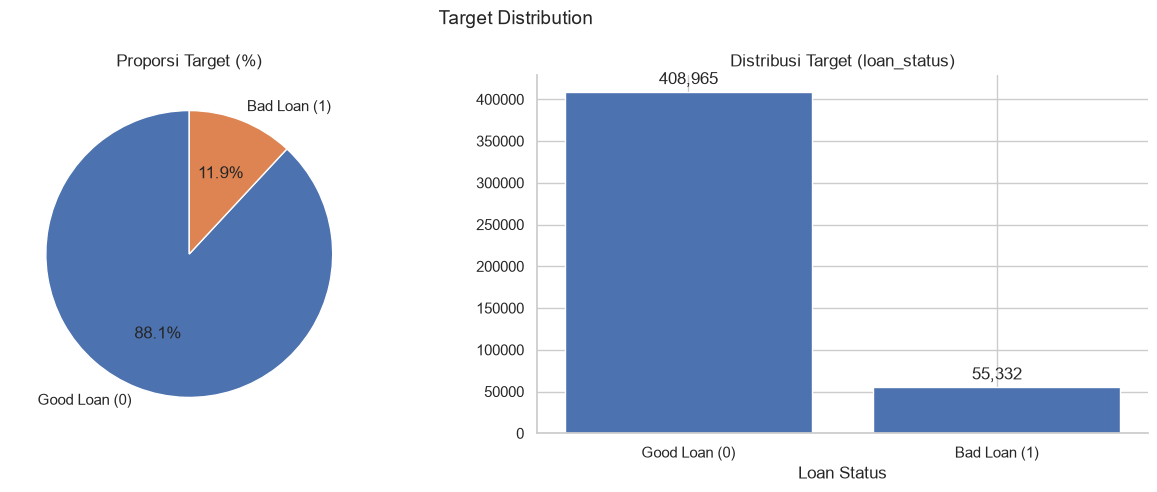

Imbalance Ratio (Good:Bad) = 7.39:1


In [13]:
# target distribution
counts = df['loan_status'].value_counts().sort_index()
labels = ['Good Loan (0)', 'Bad Loan (1)']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('Proporsi Target (%)')

bars = axes[1].bar(labels, counts.values)
axes[1].set_xlabel('Loan Status')
axes[1].set_title('Distribusi Target (loan_status)')
axes[1].spines[['top', 'right']].set_visible(False)

axes[1].bar_label(bars, labels=[f'{x:,}' for x in counts], padding=3)

plt.suptitle('Target Distribution', fontsize=14)
plt.tight_layout()
plt.show()
print(f'Imbalance Ratio (Good:Bad) = {counts[0]/counts[1]:.2f}:1')

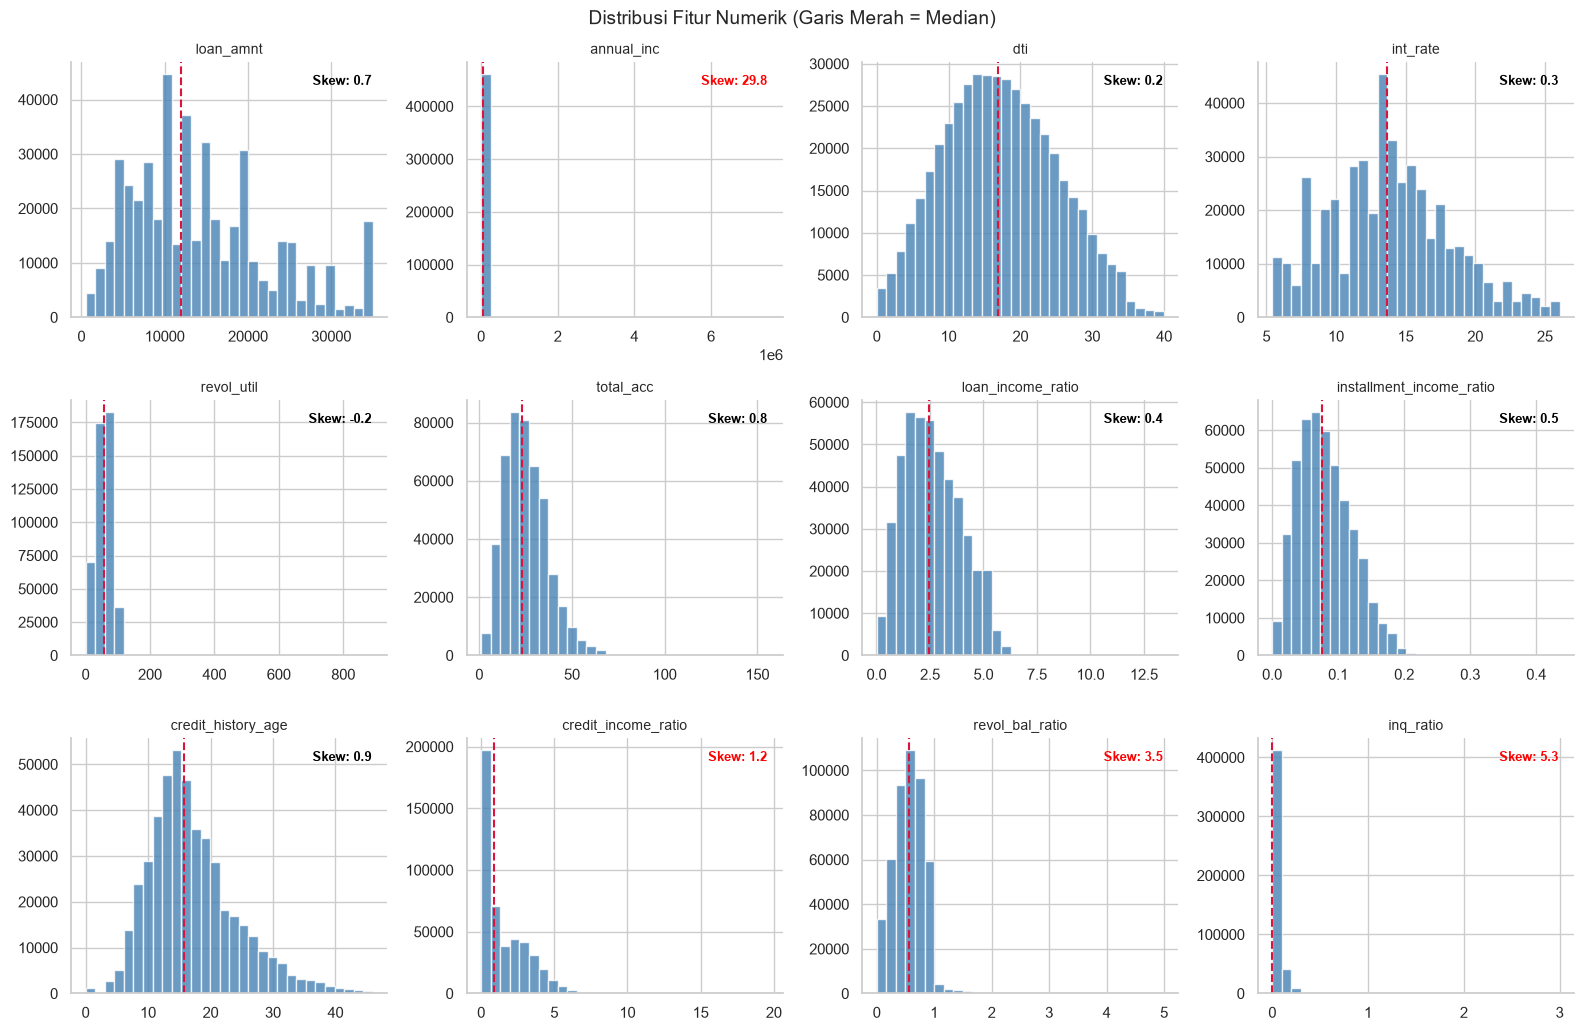

In [14]:
selected_num = [
    'loan_amnt',
    'annual_inc',
    'dti',
    'int_rate',
    'revol_util',
    'total_acc',
    'loan_income_ratio',
    'installment_income_ratio',
    'credit_history_age',
    'credit_income_ratio',
    'revol_bal_ratio',
    'inq_ratio',
]

top_num_cols = [col for col in selected_num if col in df.columns]

N_COLS_GRID = 4
n_rows_grid = (len(top_num_cols) + N_COLS_GRID - 1) // N_COLS_GRID

fig, axes = plt.subplots(n_rows_grid, N_COLS_GRID, figsize=(16, n_rows_grid * 3.5))
axes_flat = axes.flatten()

for i, col in enumerate(top_num_cols):
    ax = axes_flat[i]
    data = df[col].dropna()

    ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)

    median_val = data.median()
    ax.axvline(median_val, color='crimson', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.2f}')

    skew_val = data.skew()
    skew_color = 'red' if abs(skew_val) > 1 else 'black'
    ax.text(
        0.95, 0.95, f'Skew: {skew_val:.1f}',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=9, color=skew_color, weight='bold',
    )

for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.suptitle('Distribusi Fitur Numerik (Garis Merah = Median)', fontsize=14)
plt.tight_layout()
plt.show()

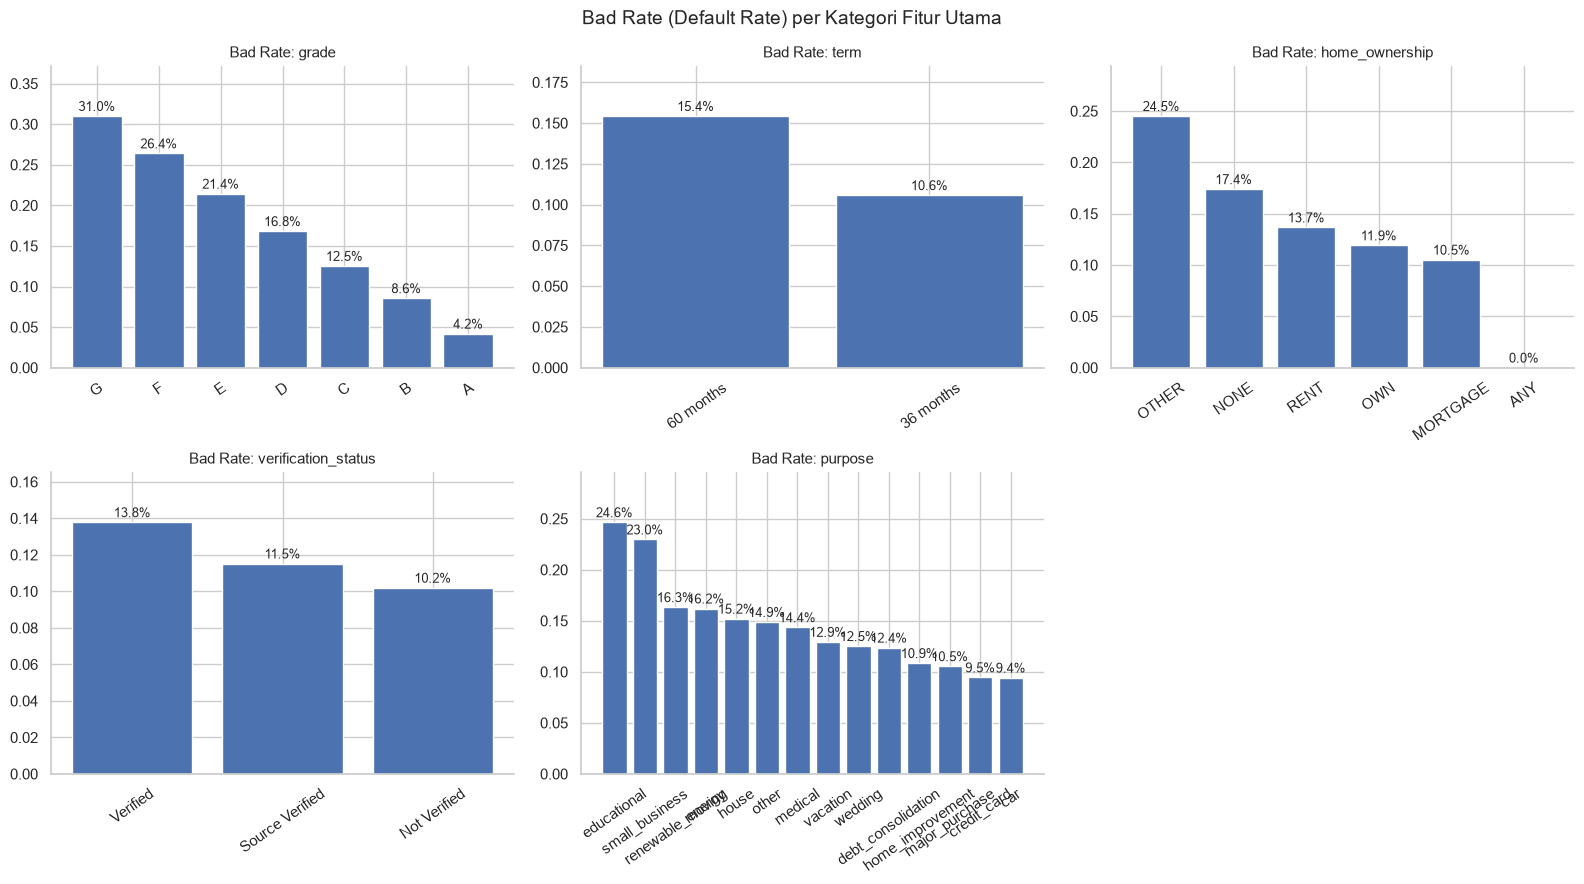

In [15]:
# Bad Rate per Kategori
cat_cols = [
    col for col in ['grade', 'term', 'home_ownership', 'verification_status', 'purpose']
    if col in df.columns
]

if cat_cols:
    n_cats = len(cat_cols)
    ncols = 3
    nrows = (n_cats + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4.5))
    axes = axes.flatten()

    for ax, col in zip(axes, cat_cols):
        default_rate = df.groupby(col)['loan_status'].mean().sort_values(ascending=False)
        bars = ax.bar(default_rate.index.astype(str), default_rate.values)

        ax.set_title(f'Bad Rate: {col}', fontsize=11)
        ax.tick_params(axis="x", rotation=35)
        y_max = default_rate.max() if default_rate.max() > 0 else 0.1
        ax.set_ylim(0, y_max * 1.2)
        ax.spines[["top", "right"]].set_visible(False)

        for bar, val in zip(bars, default_rate.values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val + y_max * 0.02,
                f"{val:.1%}",
                ha="center", fontsize=9,
            )

    for j in range(len(cat_cols), len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle('Bad Rate (Default Rate) per Kategori Fitur Utama', fontsize=14)
    plt.tight_layout()
    plt.show()

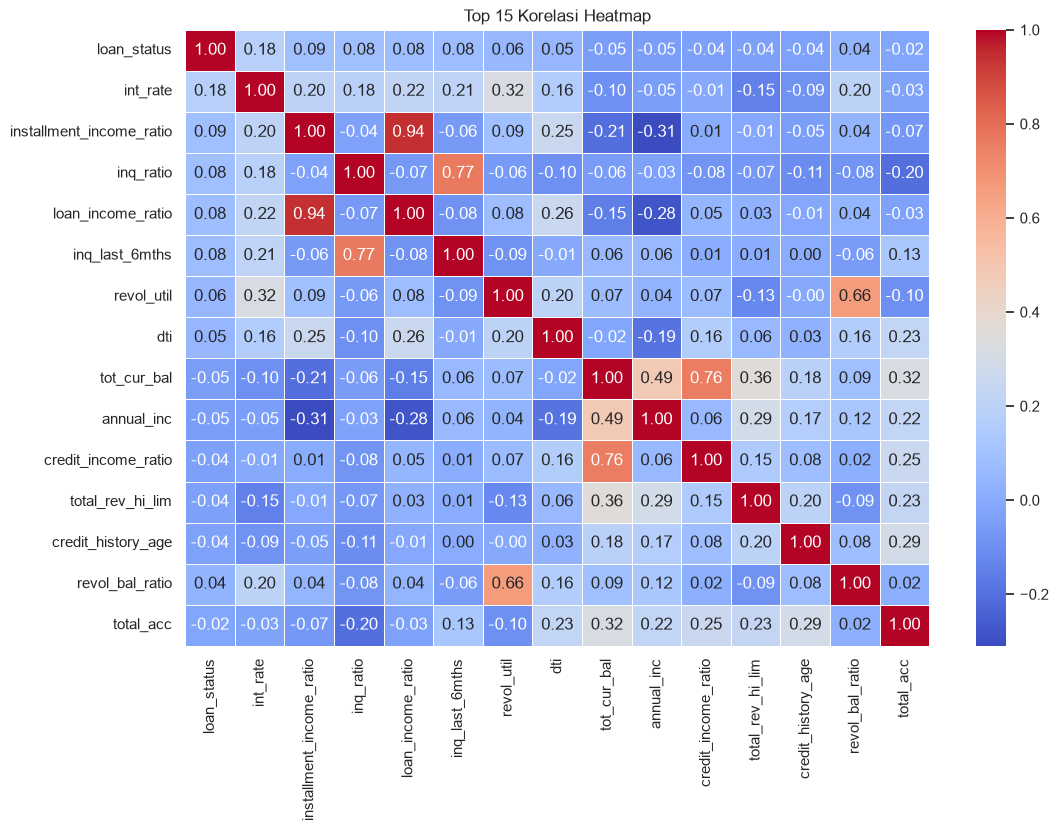

In [16]:
# Correlation heatmap
num_cols = df.select_dtypes(include=[np.number])
corr     = num_cols.corr()['loan_status'].abs().sort_values(ascending=False).head(15)
plt.figure(figsize=(12, 8))
sns.heatmap(
    num_cols[corr.index].corr(),
    cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5
)
plt.title('Top 15 Korelasi Heatmap')
plt.show()

In [17]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['loan_status'])
y = df['loan_status']

# Stratified Data Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

# Stratification Verification
train_ratio = y_train.mean()
test_ratio = y_test.mean()

print('DATA SPLIT')
print(f'Train shape : {X_train.shape}')
print(f'Test shape  : {X_test.shape}')
print(f'Train Bad Rate  : {train_ratio:.2%}')
print(f'Test Bad Rate   : {test_ratio:.2%}')

# Calculate scale_pos_weight
n_good = (y_train == 0).sum()
n_bad = (y_train == 1).sum()
scale_pos_weight = n_good / n_bad

print('-' * 25)

print(f'Class 0 (Good)  : {n_good}')
print(f'Class 1 (Bad)   : {n_bad}')
print(f'Scale Pos Weight    : {scale_pos_weight:.2f}')

DATA SPLIT
Train shape : (371437, 34)
Test shape  : (92860, 34)
Train Bad Rate  : 11.92%
Test Bad Rate   : 11.92%
-------------------------
Class 0 (Good)  : 327171
Class 1 (Bad)   : 44266
Scale Pos Weight    : 7.39


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, recall_score, precision_score, f1_score, precision_recall_curve, auc, roc_auc_score, brier_score_loss
from sklearn.calibration import CalibratedClassifierCV
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# Identify columns
CAT_COLS = [c for c in ['grade', 'term', 'home_ownership', 'verification_status', 'purpose'] if c in df.columns]
NUM_COLS = X_train.select_dtypes(include='number').columns.tolist()


preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), NUM_COLS),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
    ]), CAT_COLS),
], remainder='drop')

# Pipeline Baseline Class Weight
pipe_lr = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', LogisticRegression(
        solver='liblinear',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        max_iter=1000,
    )),
])

# Pipeline Tree-Based Models tetap dipertahankan
pipe_xgb = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        n_jobs=1,
    )),
])

pipe_lgb = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', LGBMClassifier(
        random_state=RANDOM_STATE,
        is_unbalance=True,
        verbose=-1,
        n_jobs=1,
    )),
])

print('Pipeline berhasil didefinisikan.')

Pipeline berhasil didefinisikan.


In [19]:
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring_metrics = {
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

models_to_test = {
    'Logistic Regression (Class Weight)': pipe_lr,
    'XGBoost (Baseline)': pipe_xgb,
    'LightGBM (Baseline)': pipe_lgb
}

results = []

# Looping evaluasi untuk setiap pipeline
for name, pipeline in models_to_test.items():
    print(f'Mengevaluasi {name}')
    cv_results = cross_validate(
        pipeline, X_train, y_train, 
        cv=cv, scoring=scoring_metrics, n_jobs=-1
    )
    
    results.append({
        'Model Name': name,
        'Recall (Bad Loan)': cv_results['test_recall'].mean(),
        'Precision (Bad Loan)': cv_results['test_precision'].mean(),
        'F1-Score': cv_results['test_f1'].mean(),
        'ROC-AUC': cv_results['test_roc_auc'].mean()
    })

cv_summary = pd.DataFrame(results)

print('Hasil Evaluasi Cross-Validation (Sebelum Hyperparameter Tuning)')
print(cv_summary.to_string(index=False, formatters={
    'Recall (Bad Loan)': '{:,.2%}'.format,
    'Precision (Bad Loan)': '{:,.2%}'.format,
    'F1-Score': '{:,.2%}'.format,
    'ROC-AUC': '{:,.2%}'.format
}))

Mengevaluasi Logistic Regression (Class Weight)
Mengevaluasi XGBoost (Baseline)
Mengevaluasi LightGBM (Baseline)
Hasil Evaluasi Cross-Validation (Sebelum Hyperparameter Tuning)
                        Model Name Recall (Bad Loan) Precision (Bad Loan) F1-Score ROC-AUC
Logistic Regression (Class Weight)            64.57%               18.58%   28.86%  68.04%
                XGBoost (Baseline)            60.71%               19.35%   29.34%  68.46%
               LightGBM (Baseline)            66.10%               19.03%   29.55%  69.42%


In [20]:
SEARCH_CONFIGS = {
    'Logistic + Class Weight': {
        'pipeline': pipe_lr, 
        'param_dist': {'model__C': [0.01, 0.1, 1, 10]}, 
        'n_iter': 4
    }, 
    'XGBoost': { 
        'pipeline': pipe_xgb, 
        'param_dist': { 
            'model__n_estimators': [50, 100, 200],     # Ditambahkan nilai list
            'model__max_depth': [3, 5, 7],             # Ditambahkan nilai list
            'model__learning_rate': [0.01, 0.05, 0.1], 
            'model__subsample': [0.8, 1.0], 
            'model__colsample_bytree': [0.8, 1.0], 
            'model__gamma': [0, 0.1, 0.2],             # Ditambahkan nilai list
            'model__reg_lambda': [1, 3, 5] 
        }, 
        'n_iter': 15 
    }, 
    'LightGBM': { 
        'pipeline': pipe_lgb, 
        'param_dist': { 
            'model__n_estimators': [50, 100, 200],     # Ditambahkan nilai list
            'model__max_depth': [3, 5, 7],             # Ditambahkan nilai list
            'model__learning_rate': [0.01, 0.05, 0.1], 
            'model__num_leaves': [15, 31, 63],          # Ditambahkan nilai list
            'model__subsample': [0.8, 1.0], 
            'model__colsample_bytree': [0.8, 1.0], 
            'model__min_child_samples': [10, 20, 30],  # Ditambahkan nilai list
            'model__reg_alpha': [0, 0.5, 1], 
            'model__reg_lambda': [0, 1, 3] 
        }, 
        'n_iter': 15 
    } 
}


best_models = {}

for model_name, cfg in SEARCH_CONFIGS.items():
    print(f'\nTuning Model: {model_name}')
    search = RandomizedSearchCV(
        estimator=cfg['pipeline'],
        param_distributions=cfg['param_dist'],
        n_iter=cfg['n_iter'],
        scoring='recall',
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=0,
        refit=True,
        return_train_score=True
    )
    search.fit(X_train, y_train)
    print(f'Best CV Recall: {search.best_score_:.4f}')
    
    # Pantau Overfitting Gap
    cv_res = pd.DataFrame(search.cv_results_).sort_values('mean_test_score', ascending=False).iloc[0]
    print(f'Gap Analysis    : Train Recall ({cv_res['mean_train_score']:.4f}) | CV Test Recall ({cv_res['mean_test_score']:.4f})')
    
    best_models[model_name] = search.best_estimator_    


Tuning Model: Logistic + Class Weight
Best CV Recall: 0.6457
Gap Analysis    : Train Recall (0.6470) | CV Test Recall (0.6457)

Tuning Model: XGBoost
Best CV Recall: 0.6759
Gap Analysis    : Train Recall (0.6786) | CV Test Recall (0.6759)

Tuning Model: LightGBM
Best CV Recall: 0.6691
Gap Analysis    : Train Recall (0.6761) | CV Test Recall (0.6691)


In [21]:
calibrated_models = {}
for name, model in best_models.items():
    print(f'Mengalibrasi probabilitas untuk: {name}')
    calibrated = CalibratedClassifierCV(estimator=model, method='sigmoid', cv=5)
    calibrated.fit(X_train, y_train)
    calibrated_models[name] = calibrated

Mengalibrasi probabilitas untuk: Logistic + Class Weight
Mengalibrasi probabilitas untuk: XGBoost
Mengalibrasi probabilitas untuk: LightGBM


In [23]:
# FINAL EVALUATION & BUSINESS RANKING
print('FINAL PERFORMANCE EVALUATION ON TEST DATA')

final_results = []
saved_probabilities = {}

for name, model in calibrated_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    
    # Simpan probabilitas untuk Tahap 7 (Threshold Optimization) dan Tahap 8 (SHAP)
    saved_probabilities[name] = y_prob
    
    # Kalkulasi Metrik Finansial Khusus
    rec = recall_score(y_test, y_pred, pos_label=1)
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall_vals, precision_vals)
    brier = brier_score_loss(y_test, y_prob)
    
    final_results.append({
        'Model Name': name,
        'Recall (Mitigasi Gagal Bayar)': rec,
        'PR-AUC (Stabilitas Imbalance)': pr_auc,
        'ROC-AUC': roc_auc,
        'F1-Score': f1,
        'Precision': prec,
        'Brier Score (Akurasi Probabilitas)': brier
    })

summary_df = pd.DataFrame(final_results).sort_values(
    ['Recall (Mitigasi Gagal Bayar)', 'PR-AUC (Stabilitas Imbalance)', 'ROC-AUC'], 
    ascending=[False, False, False]
)

display(summary_df.style.format({
    'Recall (Mitigasi Gagal Bayar)': '{:.2%}',
    'PR-AUC (Stabilitas Imbalance)': '{:.2%}',
    'ROC-AUC': '{:.2%}',
    'F1-Score': '{:.2%}',
    'Precision': '{:.2%}',
    'Brier Score (Akurasi Probabilitas)': '{:.4f}'
}))

FINAL PERFORMANCE EVALUATION ON TEST DATA


,Model Name,Recall (Mitigasi Gagal Bayar),PR-AUC (Stabilitas Imbalance),ROC-AUC,F1-Score,Precision,Brier Score (Akurasi Probabilitas)
0,Logistic + Class Weight,0.14%,21.98%,68.41%,0.29%,41.03%,0.1001
2,LightGBM,0.07%,24.38%,69.52%,0.14%,100.00%,0.0991
1,XGBoost,0.00%,23.06%,68.80%,0.00%,0.00%,0.0998


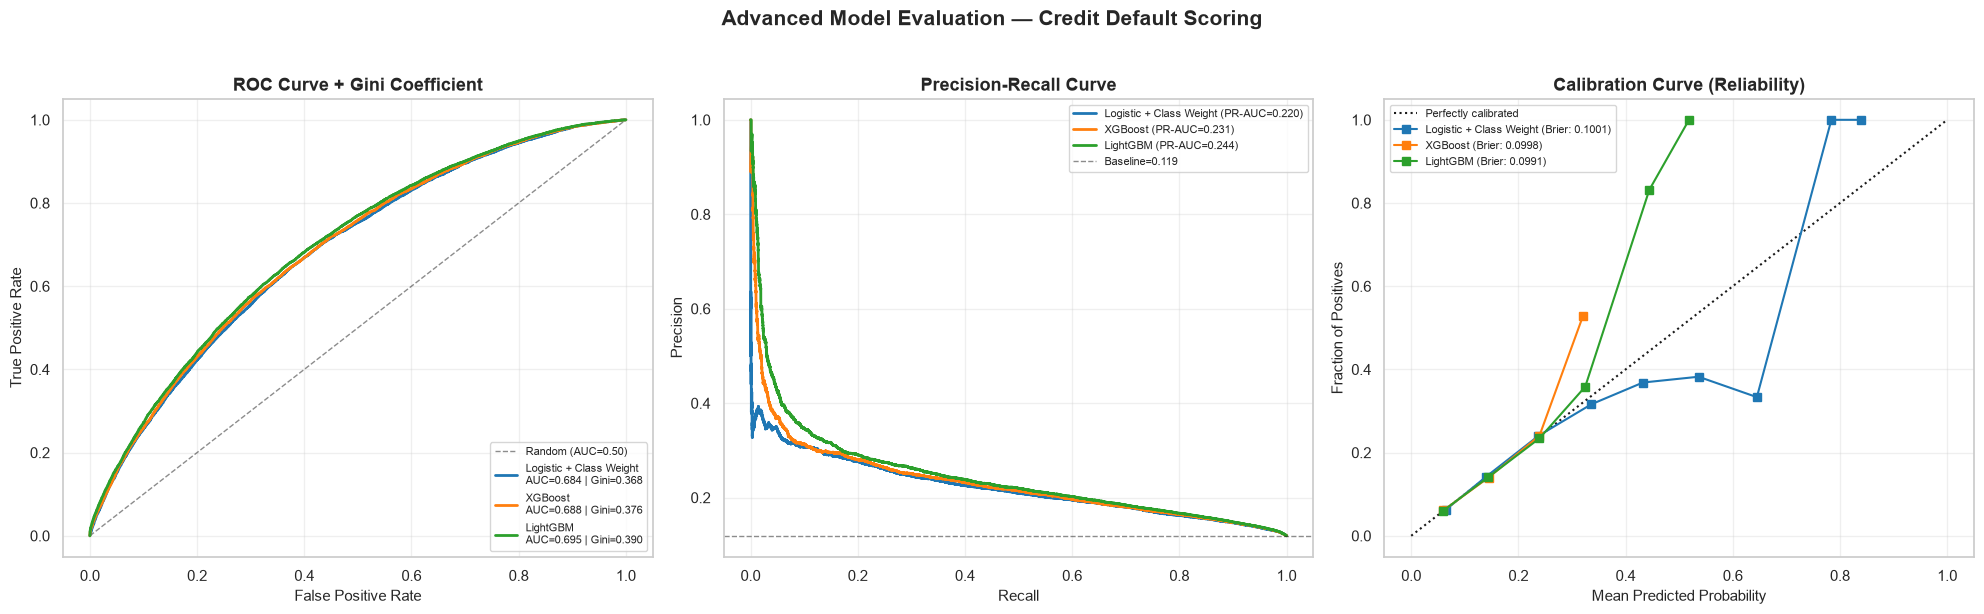

Model terbaik berdasarkan prioritas bisnis (Recall): Logistic + Class Weight


In [37]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# 1. Pastikan daftar warna didefinisikan terlebih dahulu (sesuaikan jumlahnya dengan modelmu)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# ROC Curve + Gini
ax1.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC=0.50)')
# PERBAIKAN: Tambahkan list 'colors' ke dalam zip()
for (name, model), color in zip(calibrated_models.items(), colors):
    y_prob = saved_probabilities[name]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = summary_df.loc[summary_df['Model Name'] == name, 'ROC-AUC'].values[0]
    gini = 2 * roc_auc - 1
    ax1.plot(fpr, tpr, color=color, lw=2, label=f"{name}\nAUC={roc_auc:.3f} | Gini={gini:.3f}")
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate', fontsize=11)
ax1.set_title('ROC Curve + Gini Coefficient', fontsize=13, fontweight='bold')
ax1.legend(fontsize=8, loc='lower right')
ax1.grid(alpha=0.3)


# Precision-Recall Curve
for (name, model), color in zip(calibrated_models.items(), colors):
    y_prob = saved_probabilities[name]
    prec_c, rec_c, _ = precision_recall_curve(y_test, y_prob)
    
    # PERBAIKAN: Nama kolom disesuaikan dengan isi summary_df kamu
    pr_auc = summary_df.loc[summary_df['Model Name'] == name, 'PR-AUC (Stabilitas Imbalance)'].values[0]
    
    ax2.plot(rec_c, prec_c, color=color, lw=2, label=f"{name} (PR-AUC={pr_auc:.3f})")

baseline = y_test.mean()
ax2.axhline(baseline, color='k', ls='--', lw=1, alpha=0.5, label=f'Baseline={baseline:.3f}')
ax2.set_xlabel('Recall', fontsize=11)
ax2.set_ylabel('Precision', fontsize=11)
ax2.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# Calibration Curve (Reliability Diagram)
ax3.plot([0, 1], [0, 1], 'k:', label='Perfectly calibrated')
# PERBAIKAN: Tambahkan list 'colors' ke dalam zip()
for (name, model), color in zip(calibrated_models.items(), colors):
    y_prob = saved_probabilities[name]
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
    brier = summary_df.loc[summary_df['Model Name'] == name, 'Brier Score (Akurasi Probabilitas)'].values[0]
    ax3.plot(prob_pred, prob_true, 's-', color=color, lw=1.5, label=f'{name} (Brier: {brier:.4f})')
ax3.set_xlabel('Mean Predicted Probability', fontsize=11)
ax3.set_ylabel('Fraction of Positives', fontsize=11)
ax3.set_title('Calibration Curve (Reliability)', fontsize=13, fontweight='bold')
ax3.legend(fontsize=8, loc='upper left')
ax3.grid(alpha=0.3)

plt.suptitle('Advanced Model Evaluation — Credit Default Scoring', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Menentukan Model Terbaik Berdasarkan Peringkat #1 di summary_df
best_name = summary_df.iloc[0]['Model Name']
best_prob = saved_probabilities[best_name]
print(f'Model terbaik berdasarkan prioritas bisnis (Recall): {best_name}')

In [38]:
from sklearn.metrics import fbeta_score, confusion_matrix

# Definisikan Asumsi Biaya Finansial Fintech (Sesuaikan dengan unit ekonomi Anda)
# Cost of False Negative (Meloloskan nasabah Bad Loan = Rugi modal pokok)
COST_FN = 10_000_000 
# Cost of False Positive (Menolak nasabah Good Loan = Kehilangan potensi bunga/pendapatan)
COST_FP = 1_500_000  

thresholds = np.arange(0.05, 0.85, 0.01)
records = []

for t in thresholds:
    y_pred_t = (best_prob >= t).astype(int)
    
    # Hitung matriks kebingungan untuk simulasi biaya
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    expected_cost = (fn * COST_FN) + (fp * COST_FP)
    
    records.append({
        'threshold': t,
        'recall': recall_score(y_test, y_pred_t, zero_division=0),
        'precision': precision_score(y_test, y_pred_t, zero_division=0),
        'f1': f1_score(y_test, y_pred_t, zero_division=0),
        'f2': fbeta_score(y_test, y_pred_t, beta=2, zero_division=0),
        'approval_rate': 1 - y_pred_t.mean(),
        'expected_cost': expected_cost
    })

thresh_df = pd.DataFrame(records)

# Cari ambang batas optimal berdasarkan Biaya Terendah (Prinsip Utama Fintech Risk)
best_t_idx = thresh_df['expected_cost'].idxmin()
optimal_threshold = thresh_df.loc[best_t_idx, 'threshold']
opt = thresh_df.loc[best_t_idx]

print(f'=== THRESHOLD OPTIMIZATION RESULTS ({best_name}) ===')
print(f'Optimal Threshold (Min Cost) : {optimal_threshold:.2f}')
print(f'Recall pada Threshold Ini     : {opt["recall"]:.4f}')
print(f'Precision pada Threshold Ini  : {opt["precision"]:.4f}')
print(f'F1-Score / F2-Score           : {opt["f1"]:.4f} / {opt["f2"]:.4f}')
print(f'Approval Rate                 : {opt["approval_rate"]*100:.1f}%')
print(f'Total Expected Financial Loss : Rp {int(opt["expected_cost"]):,}')

=== THRESHOLD OPTIMIZATION RESULTS (Logistic + Class Weight) ===
Optimal Threshold (Min Cost) : 0.12
Recall pada Threshold Ini     : 0.6475
Precision pada Threshold Ini  : 0.1881
F1-Score / F2-Score           : 0.2915 / 0.4350
Approval Rate                 : 59.0%
Total Expected Financial Loss : Rp 85,403,500,000


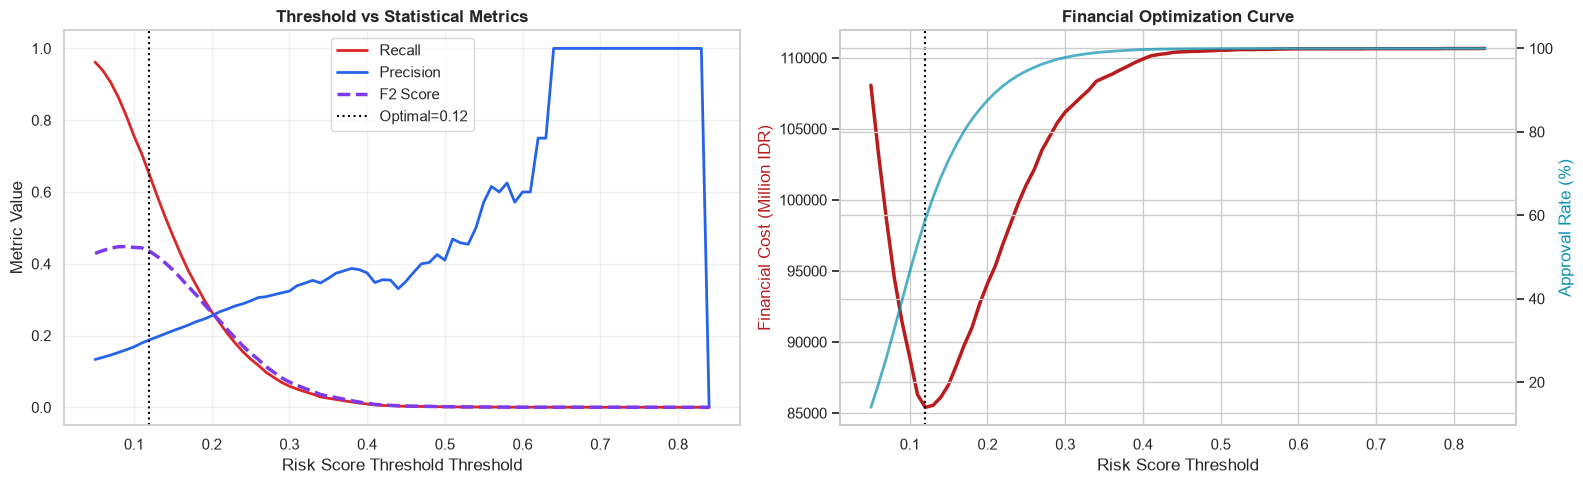

In [39]:
# --- Visualisasi Threshold Sweeps ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot Metrik Statistik
ax1.plot(thresh_df['threshold'], thresh_df['recall'], color='#dc2626', lw=2, label='Recall')
ax1.plot(thresh_df['threshold'], thresh_df['precision'], color='#2563eb', lw=2, label='Precision')
ax1.plot(thresh_df['threshold'], thresh_df['f2'], color='#7c3aed', lw=2.5, ls='--', label='F2 Score')
ax1.axvline(optimal_threshold, color='black', ls=':', lw=1.5, label=f'Optimal={optimal_threshold:.2f}')
ax1.set_xlabel('Risk Score Threshold Threshold')
ax1.set_ylabel('Metric Value')
ax1.set_title('Threshold vs Statistical Metrics', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot Dampak Finansial (Expected Cost & Approval Rate)
ax2.plot(thresh_df['threshold'], thresh_df['expected_cost'] / 1_000_000, color='#b91c1c', lw=2.5, label='Expected Cost (Juta Rp)')
ax2_twin = ax2.twinx()
ax2_twin.plot(thresh_df['threshold'], thresh_df['approval_rate'] * 100, color='#0891b2', lw=2, label='Approval Rate (%)', alpha=0.7)
ax2.axvline(optimal_threshold, color='black', ls=':', lw=1.5)
ax2.set_xlabel('Risk Score Threshold')
ax2.set_ylabel('Financial Cost (Million IDR)', color='#b91c1c')
ax2_twin.set_ylabel('Approval Rate (%)', color='#0891b2')
ax2.set_title('Financial Optimization Curve', fontweight='bold')
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

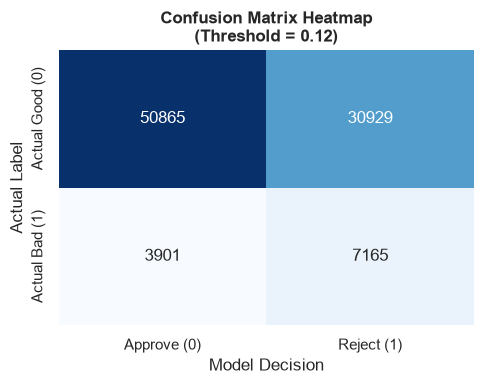

In [41]:
# --- Confusion Matrix Heatmap ---
y_pred_optimal = (best_prob >= optimal_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_optimal)

plt.figure(figsize=(5, 4))
# PERBAIKAN: Ganti fmt='s' menjadi fmt='d' agar membaca data sebagai integer
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Approve (0)', 'Reject (1)'],
            yticklabels=['Actual Good (0)', 'Actual Bad (1)'])
plt.xlabel('Model Decision')
plt.ylabel('Actual Label')
plt.title(f'Confusion Matrix Heatmap\n(Threshold = {optimal_threshold:.2f})', fontweight='bold')
plt.tight_layout()
plt.show()

In [42]:
# Membuat Dataframe Analisis Risiko
risk_analysis = pd.DataFrame({
    'Actual': y_test,
    'Probability': best_prob
})

# Kelompokkan nasabah ke dalam 4 Segmen Risiko
def assign_tier(prob):
    if prob < 0.15: return '1. Low Risk'
    elif prob < 0.35: return '2. Medium Risk'
    elif prob < 0.60: return '3. High Risk'
    else: return '4. Critical Risk'

risk_analysis['Risk Tier'] = risk_analysis['Probability'].apply(assign_tier)

# Hitung statistik per tier risiko
tier_summary = risk_analysis.groupby('Risk Tier').agg(
    Total_Nasabah=('Actual', 'count'),
    Total_Gagal_Bayar=('Actual', 'sum'),
    Bad_Rate_Aktual=('Actual', 'mean')
).reset_index()

print("\nSTRATEGI BISNIS: RISK SEGMENTATION")
print('\nStrategi Bisnis : Risk Segmentation')
display(tier_summary.style.format({
    'Total_Nasabah': '{:,}',
    'Total_Gagal_Bayar': '{:,}',
    'Bad_Rate_Aktual': '{:.2%}'
}))


STRATEGI BISNIS: RISK SEGMENTATION

Strategi Bisnis : Risk Segmentation


,Risk Tier,Total_Nasabah,Total_Gagal_Bayar,Bad_Rate_Aktual
0,1. Low Risk,"68,039","5,771",8.48%
1,2. Medium Risk,"24,039","5,014",20.86%
2,3. High Risk,777,278,35.78%
3,4. Critical Risk,5,3,60.00%


In [43]:
import shap

# 1. Ekstrak preprocessing step & model asli dari pipeline terbaik
# Catatan: Kita membedah model dasar di dalam CalibratedCV agar SHAP berjalan optimal
underlying_pipeline = calibrated_models[best_name].estimator
prep_step = underlying_pipeline.named_steps['prep']
model_step = underlying_pipeline.named_steps['model']

# 2. Rekonstruksi nama kolom setelah dibongkar ColumnTransformer
try:
    ohe = prep_step.named_transformers_['cat'].named_steps['ohe']
    cat_names = ohe.get_feature_names_out(CAT_COLS).tolist()
except Exception:
    cat_names = []
feature_names = NUM_COLS + cat_names

# Transformasikan X_test ke bentuk array numerik terproses
X_test_transformed = prep_step.transform(X_test)
if hasattr(X_test_transformed, 'toarray'):
    X_test_transformed = X_test_transformed.toarray()

X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names)

# 3. Inisialisasi Explainer SHAP secara dinamis sesuai tipe model pemenang
if 'XGBoost' in best_name or 'LightGBM' in best_name:
    explainer = shap.TreeExplainer(model_step)
else:
    # Untuk Logistic Regression, gunakan LinearExplainer
    explainer = shap.LinearExplainer(model_step, X_test_shap, feature_perturbation='interventional')

# Ambil sampel representatif agar eksekusi SHAP cepat & stabil
SAMPLE_SIZE = min(500, len(X_test_shap))
X_sample = X_test_shap.sample(SAMPLE_SIZE, random_state=42)
shap_values = explainer.shap_values(X_sample)

# Tangani perbedaan dimensi output shap antara model linear dan tree
if isinstance(shap_values, list):
    # Jika output bertipe list (klasifikasi multi-kelas/biner beberapa package lama)
    sv = shap_values[1] if len(shap_values) > 1 else shap_values[0]
elif len(shap_values.shape) == 3:
    # Struktur output shap format baru [samples, features, classes]
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

print(f'\nSHAP Engine Berhasil Diekstrak. Ukuran Matrix SHAP: {sv.shape}')

Background dataset has 92860 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=92860 when initializing the masker.



SHAP Engine Berhasil Diekstrak. Ukuran Matrix SHAP: (500, 52)


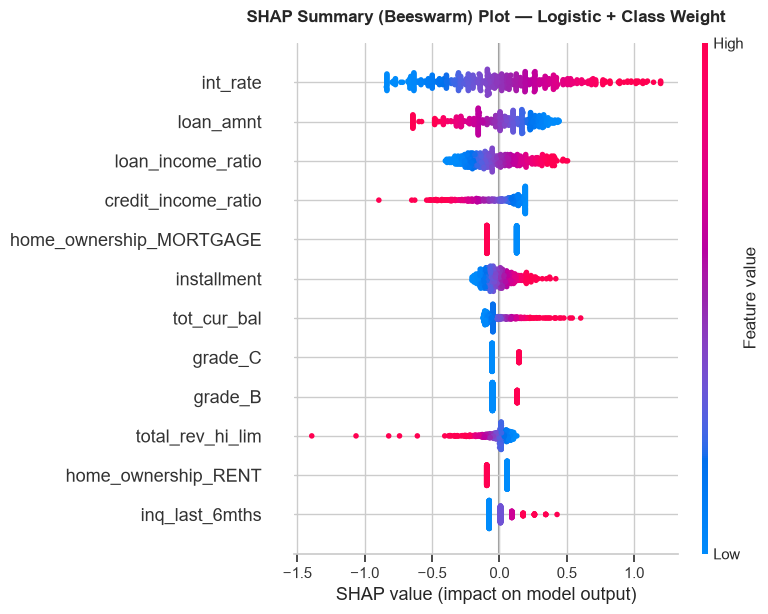

In [44]:
# --- Visualisasi SHAP Beeswarm Plot ---
plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_sample, plot_type='dot', max_display=12, show=False)
plt.title(f'SHAP Summary (Beeswarm) Plot — {best_name}', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

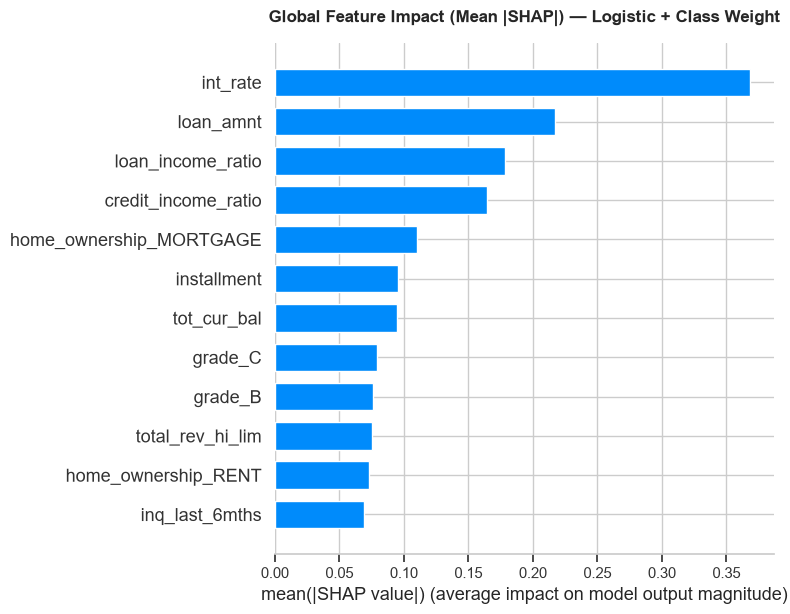

In [45]:
# --- Visualisasi SHAP Global Bar Plot ---
plt.figure(figsize=(10, 5))
shap.summary_plot(sv, X_sample, plot_type='bar', max_display=12, show=False)
plt.title(f'Global Feature Impact (Mean |SHAP|) — {best_name}', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()